In [16]:
import pandas as pd
import numpy as np

In [40]:
from PIL import Image
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

In [17]:
df1 = pd.read_csv('indiana_reports.csv')
df2 = pd.read_csv('indiana_projections.csv')

In [ ]:
# Seem like impression is the shorter description of findings -> coalesce(findings, impression)
df1['caption'] = np.where(df1['findings'].isnull(), df1['impression'], df1['findings'])

In [20]:
df1.isna().sum()

uid              0
MeSH             0
Problems         0
image            0
indication      86
comparison    1166
findings       514
impression      31
caption         25
dtype: int64

In [24]:
# Remove null caption
df1 = df1.loc[df1.caption.notnull()].reset_index(drop=True)

In [31]:
df = df1.merge(df2, on='uid', how='left')[['filename','caption']]

In [ ]:
# Replace XXXX by [MASK], these XXXX seem to be good information but somehow masked
df['caption'] = df['caption'].str.replace('XXXX', '[MASK]', regex=False)

In [47]:
df.caption.unique()[:5]

array(['The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no [MASK] of a pleural effusion. There is no evidence of pneumothorax.',
       'Borderline cardiomegaly. Midline sternotomy [MASK]. Enlarged pulmonary arteries. Clear lungs. Inferior [MASK] [MASK] [MASK].',
       'No displaced rib fractures, pneumothorax, or pleural effusion identified. Well-expanded and clear lungs. Mediastinal contour within normal limits. No acute cardiopulmonary abnormality identified.',
       'There are diffuse bilateral interstitial and alveolar opacities consistent with chronic obstructive lung disease and bullous emphysema. There are irregular opacities in the left lung apex, that could represent a cavitary lesion in the left lung apex.There are streaky opacities in the right upper lobe, [MASK] scarring. The cardiomediastinal silhouette is normal in size and contour. There is no pneumothorax or large pleural ef

In [33]:
p = 'images/images_normalized/'
df['filename'] = p+ df['filename']
df.head()

,filename,caption
0,images/images_normalized/1_IM-0001-4001.dcm.png,The cardiac silhouette and mediastinum size ar...
1,images/images_normalized/1_IM-0001-3001.dcm.png,The cardiac silhouette and mediastinum size ar...
2,images/images_normalized/2_IM-0652-1001.dcm.png,Borderline cardiomegaly. Midline sternotomy XX...
3,images/images_normalized/2_IM-0652-2001.dcm.png,Borderline cardiomegaly. Midline sternotomy XX...
4,images/images_normalized/3_IM-1384-1001.dcm.png,"No displaced rib fractures, pneumothorax, or p..."


In [48]:
class LoadDataset(Dataset):
    def __init__(self, df):
        self.images = df['filename'].values
        self.captions = df['caption'].values
    
    def __getitem__(self, idx):
        inputs = dict()
        image_path = str(self.images[idx])
        image = Image.open(image_path).convert("RGB")
        caption = self.captions[idx]
        inputs['image'] = image
        inputs['caption'] = caption
        return inputs
    
    def __len__(self):
        return len(self.images)

In [49]:
dataset = LoadDataset(df)


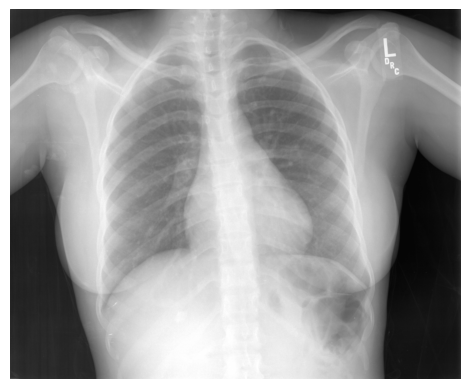

Caption: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no [MASK] of a pleural effusion. There is no evidence of pneumothorax.


In [51]:
first_item = dataset[0]

# Display the image
first_image = first_item['image']
plt.imshow(first_image)
plt.axis('off')
plt.show()

# Display the caption
first_caption = first_item['caption']
print("Caption:", first_caption)

In [52]:
# Use BLIP preprocessing for training